# Segmentador de Zona de Trabajo
La idea es **segmentar** el cable del resto de la imagen,para dejar el fondo negro y el cable a color.

## Idea general
1. Pasarle un kernel gradiente horizontal para detectar sus bordes
2. Detectar bordes de cable
3. Transformada afín???



## Librerías
Se usará OpenCV y numpy. Matplotlib sólo para visualizar las imágenes.

# Paso 0 - Cargar imágenes y librerías


In [159]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path

In [14]:

def showcv2image(img):
    #Función para mostrar OpenCV sin usar opencv
    if img is None or len(img.shape) == 2:
        plt.imshow(img, cmap='gray')
    elif img.shape[2] == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    elif img.shape[2] == 4:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGRA2RGBA))
    else:
        plt.imshow(img)
    plt.axis('off')
    plt.show()

def showallcv2images(img_list):
    #Mostrar exactamente 6 imágenes OpenCV (BGR) en una grilla 3x2.
    #Asume img_list contiene 6 elementos y cada uno es un ndarray retornado por OpenCV.
    
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    axes = axes.ravel()  # Flatten para iterar fácilmente
    for ax, img in zip(axes, img_list):
        if img is None or len(img.shape) == 2:
            ax.imshow(img, cmap='gray')
        else:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.axis('off')
    plt.tight_layout()
    plt.show()


In [161]:
path0 = str(Path.cwd()) + "/"
path1 = path0 + "B1.jpg"
path2 = path0 + "B2.jpg"
path3 = path0 + "B3.jpg"
path4 = path0 + "B4.jpg"
path5 = path0 + "B5.jpg"
path6 = path0 + "B6.jpg"

In [162]:
# Se cargan las imágenes
img1 = cv2.imread(path1)
img2 = cv2.imread(path2)
img3 = cv2.imread(path3)
img4 = cv2.imread(path4)
img5 = cv2.imread(path5)
img6 = cv2.imread(path6)
img_array = [img1, img2, img3, img4, img5, img6]

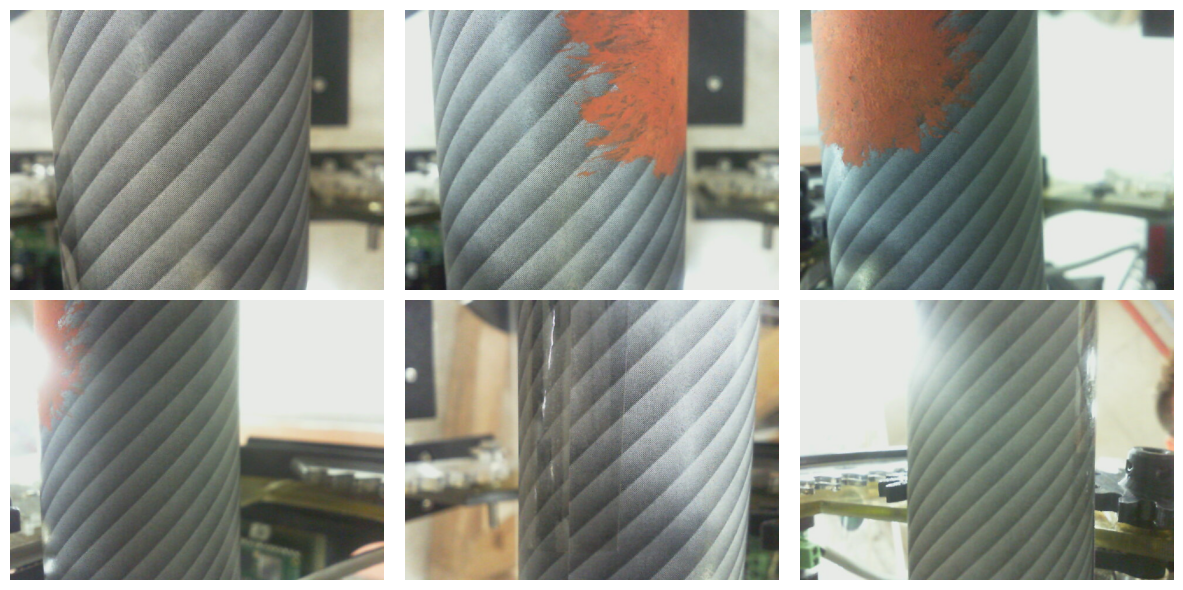

In [163]:
# Se muestran las imágenes para ver que cargaron bien
showallcv2images(img_array)

In [46]:
image = img6

# Paso 1 - Separar los canales
Para ver qué canal utilizar en la detección de bordes.

In [47]:
# Convertir la imagen de BGR a HSV
hsv_img = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
# Separar los canales HSV
h1, s1, v1 = cv2.split(hsv_img)

Hue


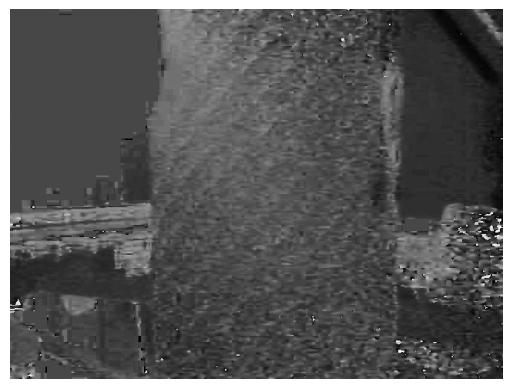

Saturation


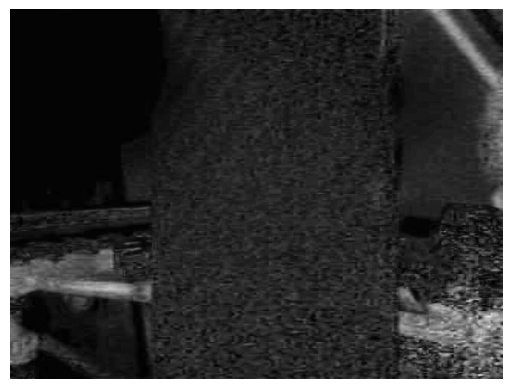

Value


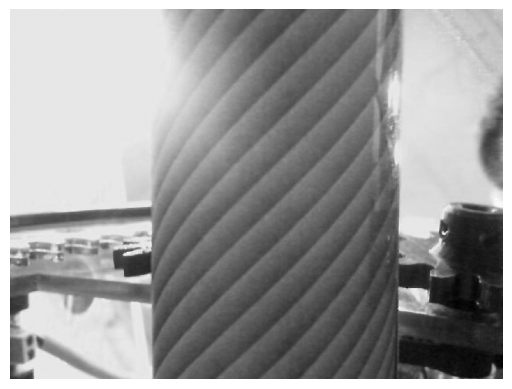

In [48]:
print("Hue")
showcv2image(h1)
print("Saturation")
showcv2image(s1)
print("Value")
showcv2image(v1)

Se usará el canal de value para la detección de bordes, ya que es en el que más fácilmente se diferencia el cable del fondo.

# Paso 2 - Detección de bordes
Ahora se detectan los bordes del cable.
Primero se prueba usar Canny. Luego se comparará con Sobel en el eje x para ver cuál funciona mejor.

In [ ]:
vchan_array = []
for img in img_array:
    # Convertir la imagen de BGR a HSV
    hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    # Separar los canales HSV
    hchan, schan, vchan = cv2.split(hsv_img)
    # Juntar los canales de value en una lista
    vchan_array.append(vchan)

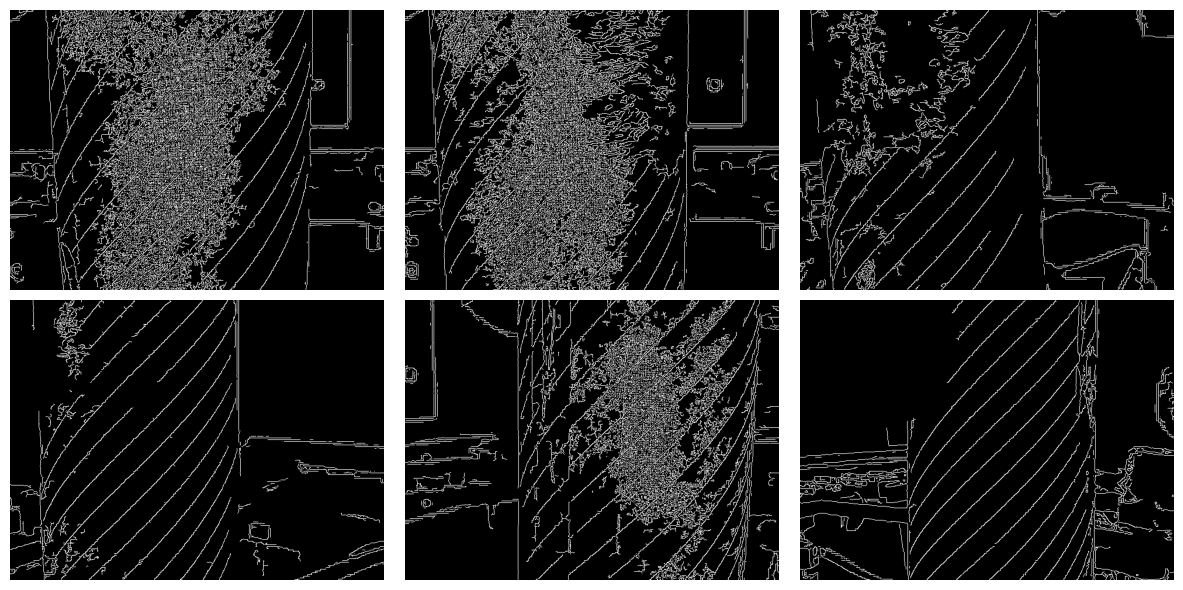

In [49]:
# Aplicar filtro Canny para comparar
canny_array = []
for img in vchan_array:
    edges = cv2.Canny(img, 30, 90)
    canny_array.append(edges)
showallcv2images(canny_array)


Se prueba Sobel en x para comparar con Canny

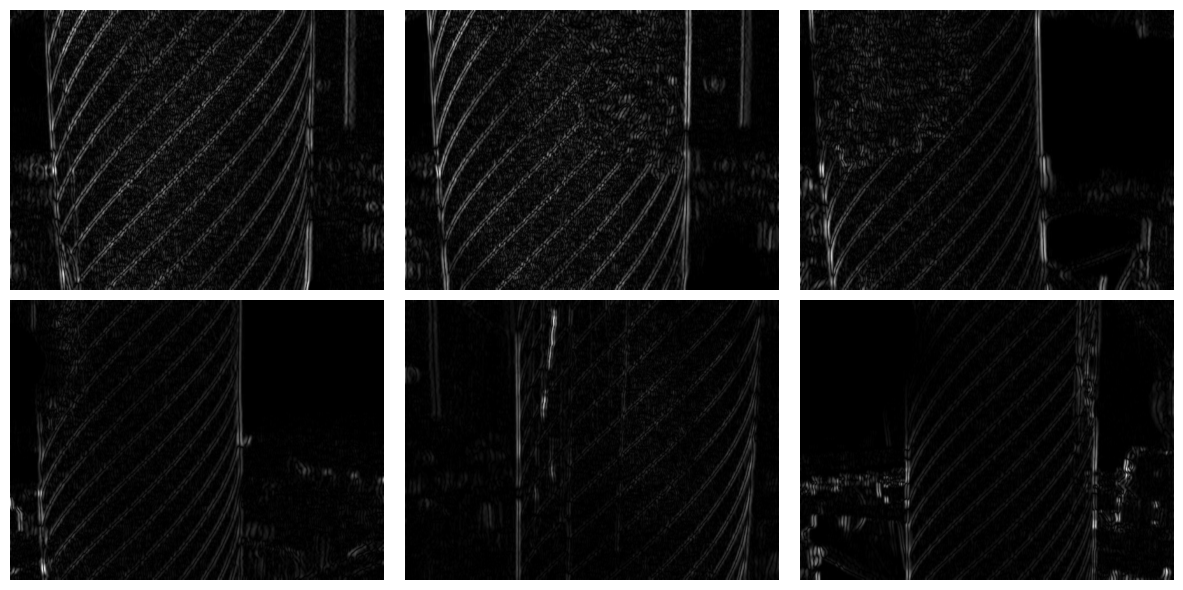

In [59]:
# Se prueba Sobel en x
sobelx_array= []
for img in vchan_array:
    # Aplicar filtro Sobel en x
    sobelx = cv2.Sobel(img, cv2.CV_64F, 2, 0, ksize=13)
    sobelx = np.absolute(sobelx)
    sobelx_norm = cv2.normalize(sobelx, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    sobelx_array.append(sobelx_norm)

showallcv2images(sobelx_array)

Vemos que el filtro Sobel da mejores resultados. Después de tunear los parámetros, se discriminarán los bordes para sólo recoger los más fuertes (se espera que dentro de los más fuertes se encuentren los del cable con el fondo)

# Paso 3 - Discriminación de bordes.
Se trabajan los bordes de la imagen para aislar los bordes suaves de los más fuertes. La idea es que el output sea binario, para poder después trabajar mejor con los bordes.

Como la imagen es bimodal (cable vs fondo), primero se intenta ver cómo funciona Otsu. Quizás no tenga tan buenos resultados, pues el cable en si tiene varios bordes entre sus alambres. 

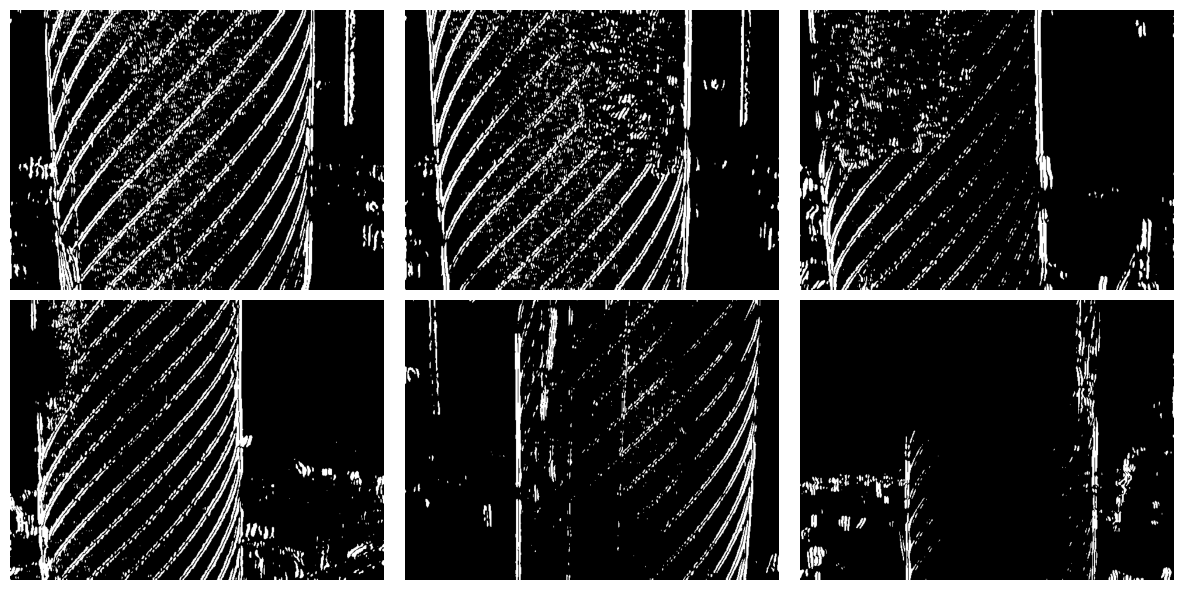

In [107]:
binary_otsu = []
otsu_vis = []
for img in sobelx_array:
    _, th = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # th ya es 0/255 uint8; convertir a 0/1 si necesitas
    mask = (th > 0).astype(np.uint8)
    binary_otsu.append(mask)
    otsu_vis.append((mask * 255).astype(np.uint8))
    
showallcv2images(otsu_vis)


Se intenta ahora filtrando solo los percentiles más altos de la imagen. 

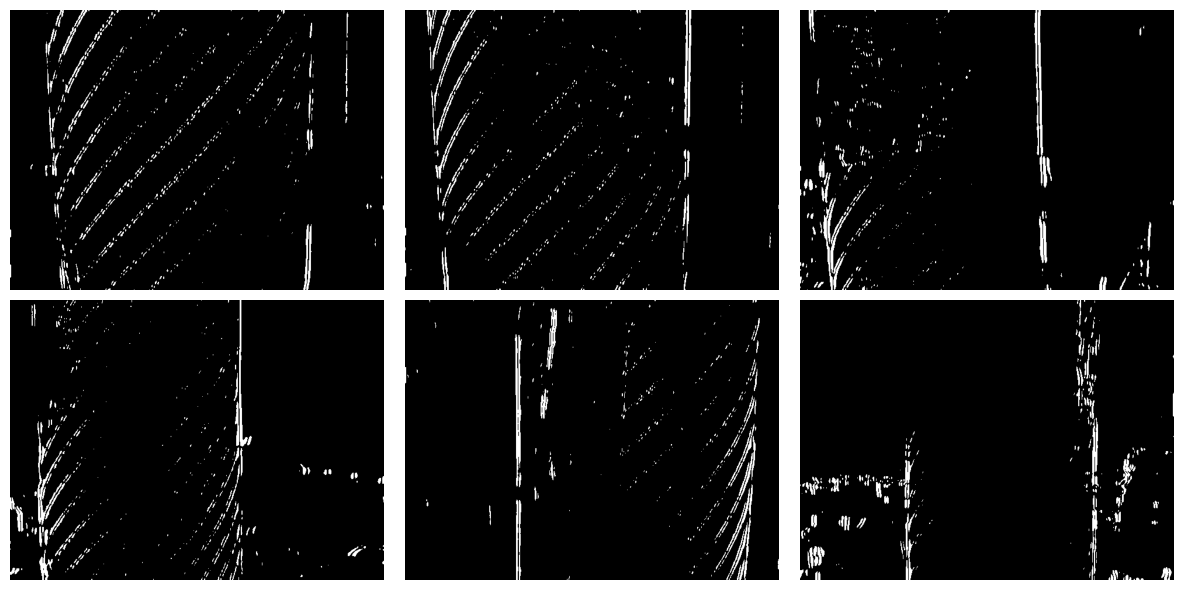

In [115]:
binary_percentile = []
percentile_vis = []
for img in sobelx_array:
    p = np.percentile(img, 97) # Obtiene el valor del percentil 98 de la imagen
    mask = (img > p).astype(np.uint8) # Filtra en base a ese valor
    binary_percentile.append(mask)
    percentile_vis.append((mask * 255).astype(np.uint8))
showallcv2images(percentile_vis)

Ambos funcionan bien y computacionalmente tienen un costo similar. Otsu funciona bien porque Sobel retorna una imagen bastante bimodal, sin embargo percentil funciona similarmente bien y confío más en su robustez, además de que computacionalmente parece ser un método más barato. 

# Paso 4 - Definición de bordes del cable
Se le pasa a la imagen un kernel vertical a lo largo de ella, para determinar los mejores candidatos a ser el borde del cable. Para esto, se busca un candidato por cada lado de la imagen (desde el centro a la izquierda hay 1 candidato, desde el centro a la derecha está el otro candidato.)

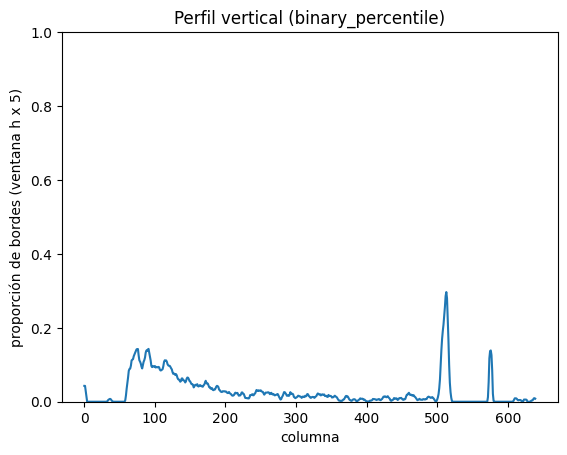

In [121]:
vertical_profiles = []   # cada elemento: array de longitud = ancho de la imagen, valores en [0,1]
kernel_width = 5

for mask in binary_percentile:
    # asegurar que mask es 0/1 y 2D
    mask2 = (mask > 0).astype(np.uint8)
    h, w = mask2.shape[:2]

    # suma por columna (número de pixeles 1 en cada columna)
    col_sum = mask2.sum(axis=0).astype(np.float64)  # length = w

    # pad reflectivo de kernel_width//2 a ambos lados para conservar tamaño
    pad = kernel_width // 2
    col_sum_padded = np.pad(col_sum, pad_width=pad, mode='reflect')

    # convolución 1D con kernel de unos (suma de ventana de ancho kernel_width)
    kernel = np.ones(kernel_width, dtype=np.float64)
    conv = np.convolve(col_sum_padded, kernel, mode='valid')  # length = w

    # promedio normalizado por (h * kernel_width) -> proporción de píxeles '1' en cada ventana
    vertical_mean = conv / (h * float(kernel_width))
    vertical_profiles.append(vertical_mean)

# Ejemplo rápido: visualizar el perfil de la primera máscara
plt.plot(vertical_profiles[0])
plt.ylim(0,1)
plt.xlabel('columna')
plt.ylabel('proporción de bordes (ventana h x 5)')
plt.title('Perfil vertical (binary_percentile)')
plt.show()

# Paso 5 - Selección de mejores candidatos
Partiendo desde el centro hacia ambos lados, se escoge un candidato por lado.

In [117]:
candidates = []
for prof in vertical_profiles:
    w = prof.shape[0]
    mid = w // 2
    left = prof[:mid]
    right = prof[mid:]

    if left.size:
        left_rel = int(np.argmax(left))
        left_idx = left_rel
        left_val = float(left[left_rel])
    else:
        left_idx, left_val = 0, 0.0

    if right.size:
        right_rel = int(np.argmax(right))
        right_idx = mid + right_rel
        right_val = float(right[right_rel])
    else:
        right_idx, right_val = w - 1, 0.0

    candidates.append((left_idx, right_idx))

print("candidates per profile (left_idx, right_idx):")
for c in candidates:
    print(c)

candidates per profile (left_idx, right_idx):
(91, 513)
(67, 481)
(49, 412)
(52, 394)
(193, 586)
(184, 502)


Ahora se visualizan los mejores candidatos encontrados.

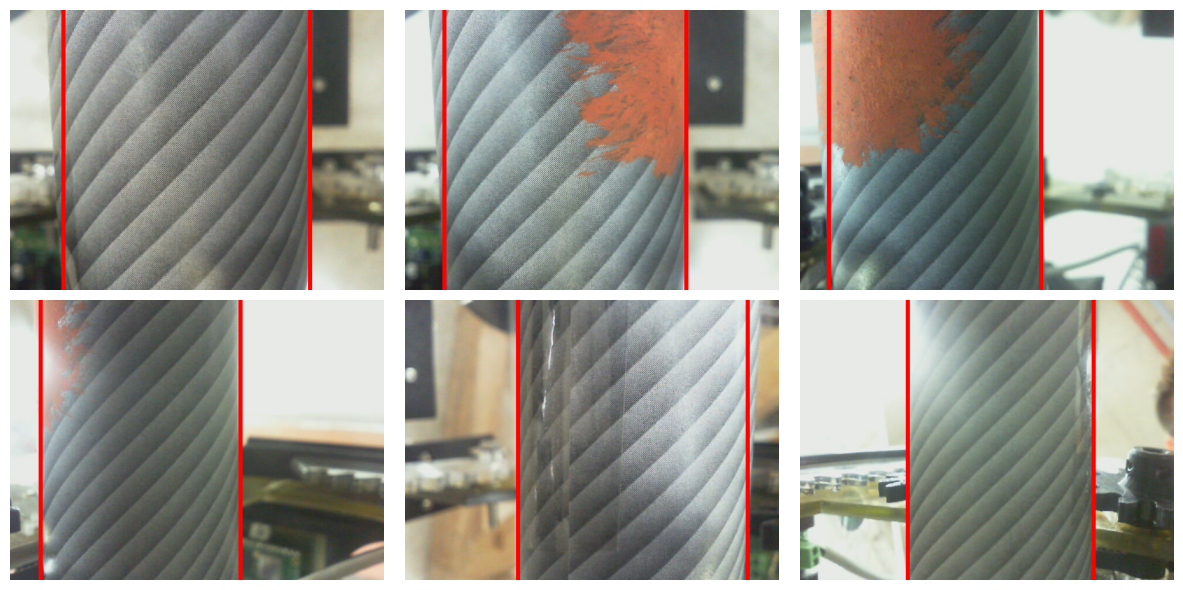

In [118]:
# Dibujar líneas verticales en left_idx y right_idx (color rojo, grosor 5)
result_with_lines = []
n = min(len(img_array), len(candidates))
for i in range(n):
    img = img_array[i]
    if img is None:
        result_with_lines.append(None)
        continue
    out = img.copy()
    h, w = out.shape[:2]
    left_idx, right_idx = candidates[i]  # candidates as (left_idx, right_idx)
    lx = int(np.clip(left_idx, 0, w-1))
    rx = int(np.clip(right_idx, 0, w-1))
    red_bgr = (0, 0, 255)  # OpenCV usa BGR
    cv2.line(out, (lx, 0), (lx, h-1), red_bgr, thickness=5)
    cv2.line(out, (rx, 0), (rx, h-1), red_bgr, thickness=5)
    result_with_lines.append(out)

# Mostrar resultados (usa la función ya definida)
showallcv2images(result_with_lines)

# Paso 6 - Recortar imagen
Se recorta la imagen para solo trabajar sobre las partes relevantes de esta. 

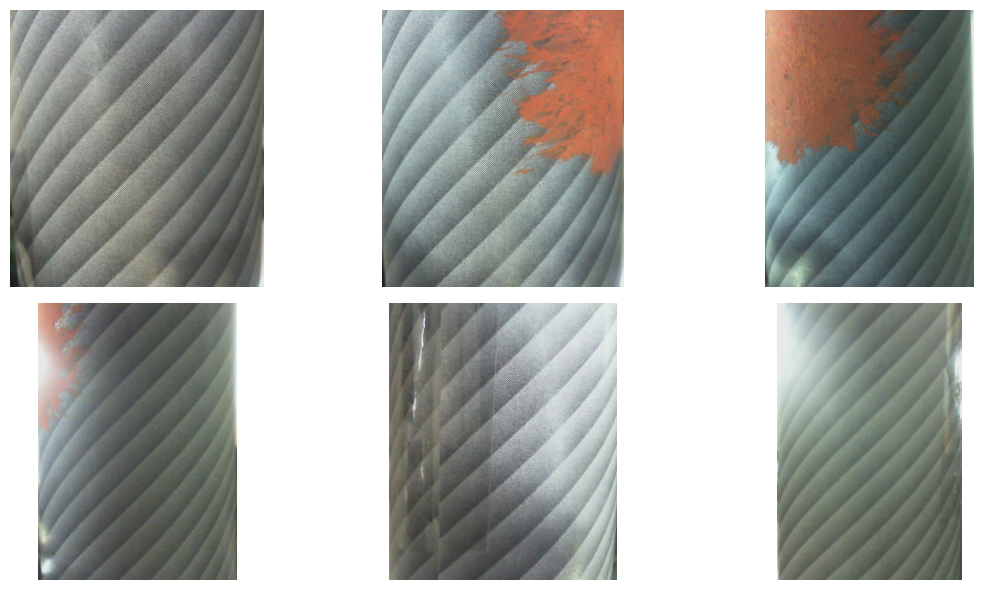

In [102]:
# Recortar, por cada imagen, el área entre left_x y right_x (inclusive) y mostrar los recortes.
cropped_list = []
n = min(len(img_array), len(candidates))
for i in range(n):
    img = img_array[i]
    # Si img es None, no hacer nada y añadir un None a la lista
    if img is None:
        cropped_list.append(None)
        continue
    
    h, w = img.shape[:2]
    left_x, right_x = candidates[i]

    crop = img[:, left_x:right_x+1].copy()  # cortar columnas entre las líneas
    cropped_list.append(crop)

# showallcv2images espera exactamente 6 elementos; rellenar con None si hace falta
if len(cropped_list) < 6:
    cropped_list += [None] * (6 - len(cropped_list))

showallcv2images(cropped_list)


Con esto, queda listo el algoritmo de segmentador de zona de trabajo. Ahora, los algoritmos de procesamiento de imágenes pueden trabajar sin preocuparse del color del fondo. 

# Función completa
Se hace la definición completa de la función para trabajar con ella en tiempo real. 

In [152]:
def segmentar_zona(img:np.ndarray, per:int=97, kernel_v_width:int=5, show_lines:bool=True) -> np.ndarray:
    """
    Retorna (cropped, out)
    - cropped: np.ndarray con el recorte entre las líneas
    - out: np.ndarray con la imagen original y líneas dibujadas, o None si show_lines=False
    """
    
    ## Paso 1 - Separar en HSV
    # Convertir la imagen de BGR a HSV
    hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    # Separar los canales HSV
    _, _, v1 = cv2.split(hsv_img)
    
    ## Paso 2 - Aplicar Sobel en x
    sobelx = cv2.Sobel(v1, cv2.CV_64F, 2, 0, ksize=13)
    sobelx = np.absolute(sobelx)
    sobelx_norm = cv2.normalize(sobelx, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    ## Paso 3 - Umbral por percentil
    p = np.percentile(sobelx_norm, per) # Obtiene el valor del percentil per de la imagen
    mask = (sobelx_norm > p).astype(np.uint8) # Filtra en base a ese valor
    
    
    ## Paso 4 - Perfil vertical
    mask2 = (mask > 0).astype(np.uint8)
    h, _ = mask2.shape[:2]
    # suma por columna (número de pixeles 1 en cada columna)
    col_sum = mask2.sum(axis=0).astype(np.float64)  # length = w
    # pad reflectivo de kernel_v_width//2 a ambos lados para conservar tamaño
    pad = kernel_v_width // 2
    col_sum_padded = np.pad(col_sum, pad_width=pad, mode='reflect')
    # convolución 1D con kernel de unos (suma de ventana de ancho kernel_v_width)
    kernel = np.ones(kernel_v_width, dtype=np.float64)
    conv = np.convolve(col_sum_padded, kernel, mode='valid')  # length = w
    # promedio normalizado por (h * kernel_v_width) -> proporción de píxeles '1' en cada ventana
    vertical_mean = conv / (h * float(kernel_v_width))

    
    ## Paso 5 - Selección de candidatos
    w = vertical_mean.shape[0]
    mid = w // 2
    left = vertical_mean[:mid]
    right = vertical_mean[mid:]
    if left.size:
        left_rel = int(np.argmax(left))
        left_idx = left_rel
    else:
        left_idx = 0
    if right.size:
        right_rel = int(np.argmax(right))
        right_idx = mid + right_rel
    else:
        right_idx = w - 1
    
    ## Paso 6 - Recorte
    cropped = img[:, left_idx:right_idx+1].copy()
    
    ## Paso 7 (opcional) - Retornar la imagen original con el borde dibujado
    if show_lines:
        out = img.copy()
        h, w = out.shape[:2]
        lx = int(np.clip(left_idx, 0, w-1))
        rx = int(np.clip(right_idx, 0, w-1))
        red_bgr = (0, 0, 255)  # OpenCV usa BGR
        cv2.line(out, (lx, 0), (lx, h-1), red_bgr, thickness=5)
        cv2.line(out, (rx, 0), (rx, h-1), red_bgr, thickness=5)
    else:
        out = None

    return cropped, out

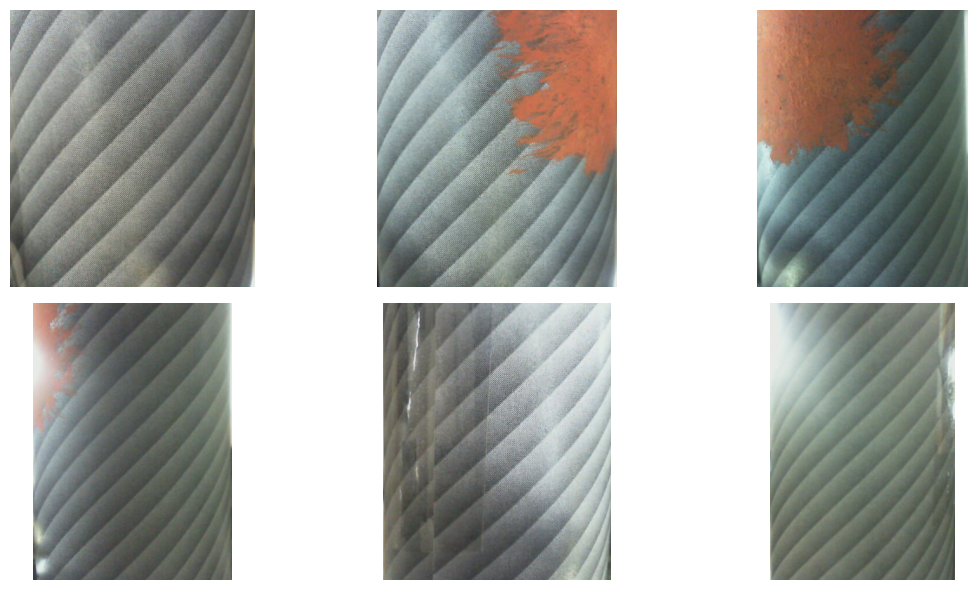

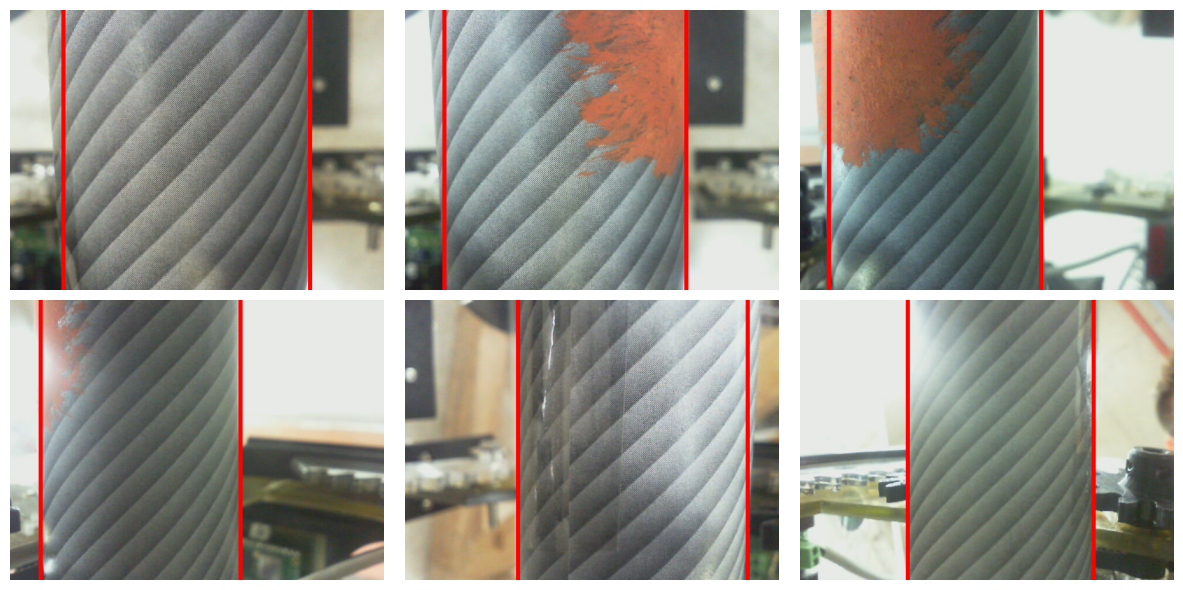

In [153]:
# Se prueba la función sobre todas las imágenes
segmented_results = []
drawn_results = []
for img in img_array:
    cropped = segmentar_zona(img)
    segmented_results.append(cropped[0])
    drawn_results.append(cropped[1])

showallcv2images(segmented_results)
showallcv2images(drawn_results)